# Preprocessing

In [1]:
from pathlib import Path
from typing import Optional
import sys
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

from src.data_processing.load_data import load_heart_data
from src.data_processing.preprocess import (
    CONTINUOUS_FEATURES,
    apply_boxcox_transform,
    encode_features,
    preprocess_data,
    split_data,
)

In [2]:
def find_project_root(start: Optional[Path] = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data" / "heart.csv").exists():
            return candidate
    raise FileNotFoundError("Project root not found (expected data/heart.csv)")

ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## Load & Check Raw Data

In [3]:
data = load_heart_data()
print("Initial shape:", data.shape)
display(data.head())
display(data.isna().sum().to_frame("missing_values"))

Initial shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


,missing_values
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


## Pipeline Preprocessing

### Encoding Categorical Features

In [4]:
data_encoded = encode_features(data)
print("Shape after encoding:", data_encoded.shape)
display(data_encoded.head())
display(data_encoded.dtypes.to_frame("dtype"))

Shape after encoding: (303, 19)


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3
0,63,1,145,233,1,150,0,2.3,0,0,1,False,False,True,False,False,True,False,False
1,37,1,130,250,0,187,0,3.5,0,0,1,False,True,False,True,False,False,True,False
2,41,0,130,204,0,172,0,1.4,2,0,1,True,False,False,False,False,False,True,False
3,56,1,120,236,0,178,0,0.8,2,0,1,True,False,False,True,False,False,True,False
4,57,0,120,354,0,163,1,0.6,2,0,1,False,False,False,True,False,False,True,False


,dtype
age,int64
sex,int64
trestbps,int64
chol,int64
fbs,int64
thalach,int64
exang,int64
oldpeak,float64
slope,int64
ca,int64


### Split Data into Train/Test Sets

In [5]:
X_train, X_test, y_train, y_test = split_data(data_encoded)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
display(y_train.value_counts(normalize=True).rename("train_ratio").to_frame())
display(y_test.value_counts(normalize=True).rename("test_ratio").to_frame())

X_train: (242, 18)
X_test: (61, 18)


,train_ratio
target,
1,0.545455
0,0.454545


,test_ratio
target,
1,0.540984
0,0.459016


### Apply Box-Cox Transformation to Continuous Features

In [6]:
X_train_boxcox, X_test_boxcox, lambdas = apply_boxcox_transform(X_train, X_test)
print("Lambda values:")
display(pd.Series(lambdas, name="lambda"))
print("Skewness before transformation:")
display(X_train[CONTINUOUS_FEATURES].skew().to_frame("skew_before"))
print("Skewness after transformation:")
display(X_train_boxcox[CONTINUOUS_FEATURES].skew().to_frame("skew_after"))

Lambda values:


age         1.188463
trestbps   -0.566962
chol       -0.125526
thalach     2.445456
oldpeak     0.177598
Name: lambda, dtype: float64

Skewness before transformation:


,skew_before
age,-0.111203
trestbps,0.611318
chol,1.324899
thalach,-0.612954
oldpeak,1.152909


Skewness after transformation:


,skew_after
age,-0.045385
trestbps,0.001195
chol,-0.009640
thalach,-0.104509
oldpeak,-0.362328


### Visualize the effect of Box-Cox Transformation

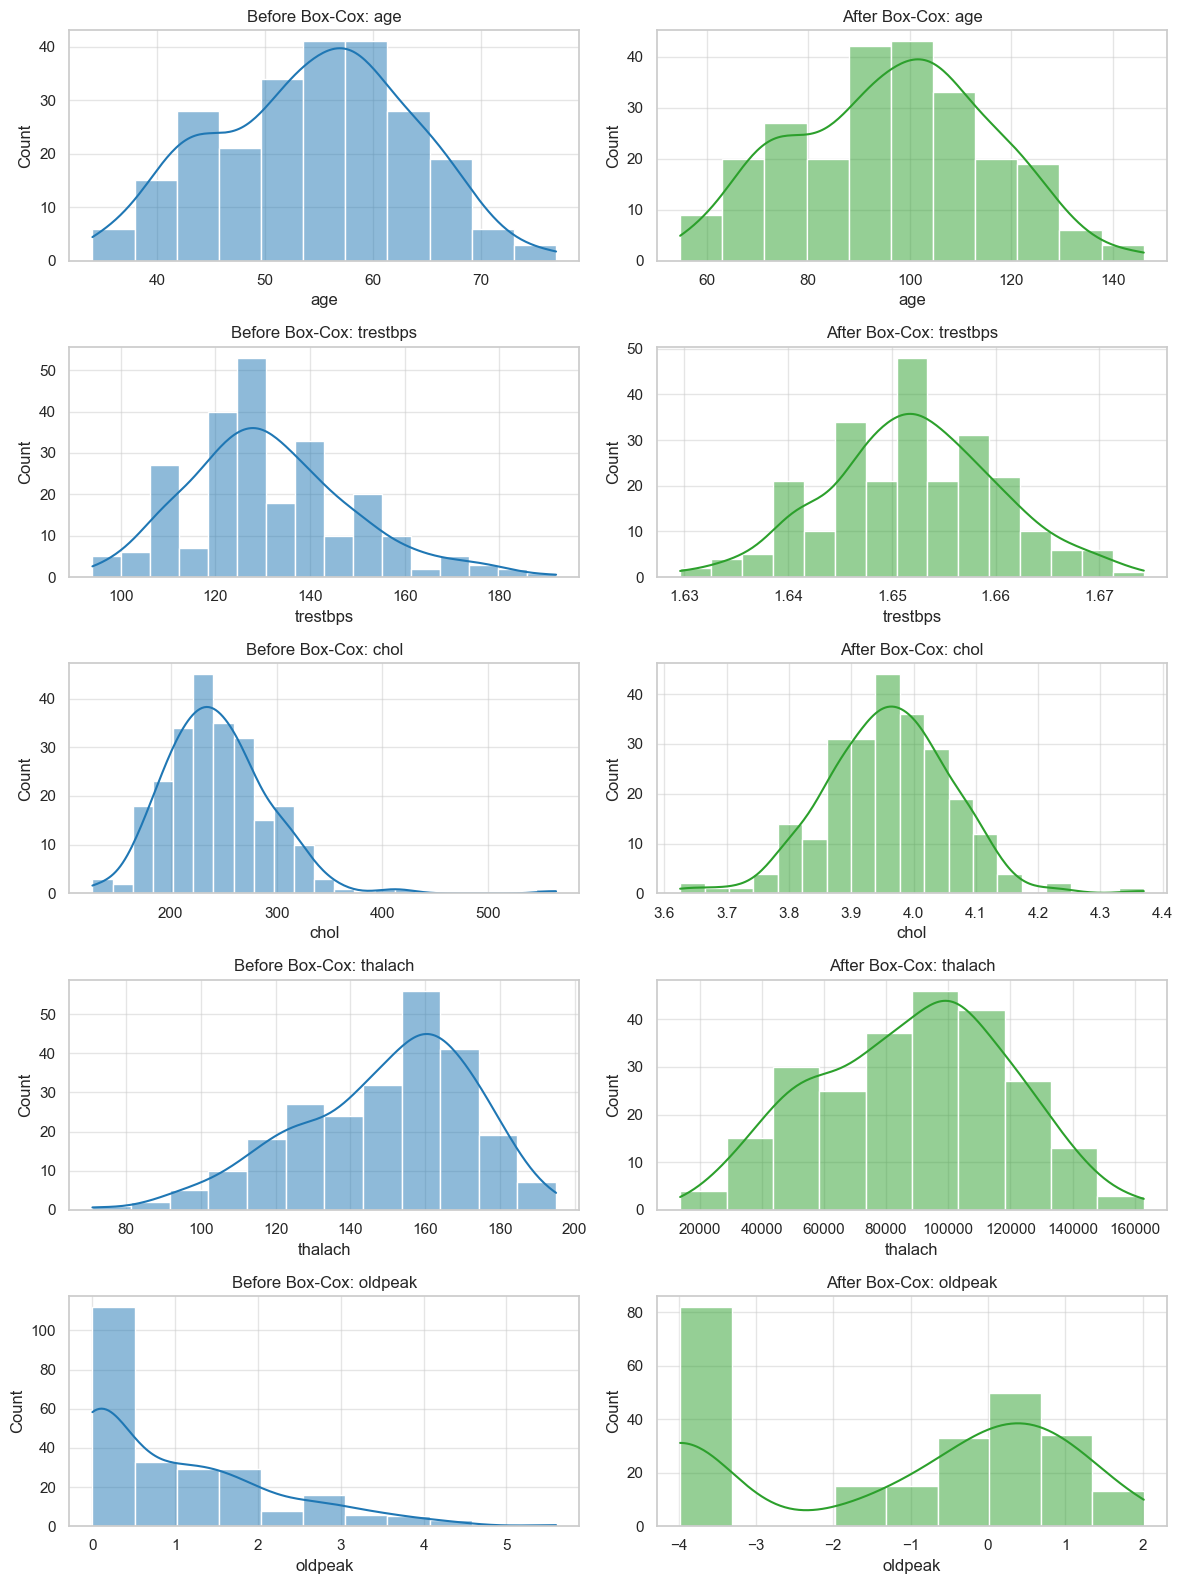

In [7]:
fig, axes = plt.subplots(len(CONTINUOUS_FEATURES), 2, figsize=(12, 16))
for idx, column in enumerate(CONTINUOUS_FEATURES):
    sns.histplot(X_train[column], kde=True, ax=axes[idx, 0], color="#1f77b4")
    axes[idx, 0].set_title(f"Before Box-Cox: {column}")
    sns.histplot(X_train_boxcox[column], kde=True, ax=axes[idx, 1], color="#2ca02c")
    axes[idx, 1].set_title(f"After Box-Cox: {column}")
plt.tight_layout()
plt.show()

### Full Preprocessing Pipeline

In [9]:
processed = preprocess_data(data)
print("Final X_train:", processed.X_train.shape)
print("Final X_test:", processed.X_test.shape)
display(processed.X_train.head())

Final X_train: (242, 18)
Final X_test: (61, 18)


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3
269,99.775363,1,1.652121,4.044511,1,34193.227632,1,0.490856,0,0,False,False,False,False,False,False,False,True
191,104.060287,1,1.651135,3.909224,0,61564.640490,1,0.846853,1,3,False,False,False,False,False,False,False,True
15,87.096593,0,1.646936,3.916243,0,97354.894861,0,0.490856,1,0,False,True,False,True,False,False,True,False
224,95.519188,1,1.641027,3.960431,0,55975.891019,1,1.130195,1,1,False,False,False,True,False,False,False,True
250,89.190732,1,1.656715,4.069855,0,51729.486474,1,1.634849,1,3,False,False,False,True,False,False,False,True


## Conclude
`preprocess_data()` tra ve mot doi tuong `ProcessedData` hoan chinh de dung cho mo hinh hoa.